In [34]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [18]:
def compute_RSI(series, period=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    avg_gain = gain.rolling(window=period, min_periods=period).mean()
    avg_loss = loss.rolling(window=period, min_periods=period).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

In [19]:
def compute_MACD(series, fast=12, slow=26, signal=9):
    ema_fast = series.ewm(span=fast, adjust=False).mean()
    ema_slow = series.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    return macd, signal_line

In [20]:
def compute_bollinger(series, window=20, num_std=2):
    rolling_mean = series.rolling(window=window).mean()
    rolling_std = series.rolling(window=window).std()
    upper_band = rolling_mean + (rolling_std * num_std)
    lower_band = rolling_mean - (rolling_std * num_std)
    return upper_band, lower_band

In [21]:
path = "datasets/mega_dataset_scaled.csv"  
df = pd.read_csv(path, parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

In [22]:
horizon = 5  
df['target'] = (df['Gold_Price'].shift(-horizon) > df['Gold_Price']).astype(int)

In [23]:
df['log_return'] = np.log(df['Gold_Price'] / df['Gold_Price'].shift(1))


df['ma_5'] = df['Gold_Price'].rolling(5).mean()
df['ma_20'] = df['Gold_Price'].rolling(20).mean()
df['ma_ratio'] = df['ma_5'] / df['ma_20']


df['volatility'] = df['log_return'].rolling(10).std()
df['RSI'] = compute_RSI(df['Gold_Price'])
df['MACD'], df['MACD_signal'] = compute_MACD(df['Gold_Price'])
df['Boll_upper'], df['Boll_lower'] = compute_bollinger(df['Gold_Price'])

c:\Users\User\dev\training_model\.venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [24]:
df.head()

,Date,Gold_Price,Crude_Oil,Inflation,Interest_Rate,USD_EUR,SLV,^GSPC,sent_enc,increase_ind,...,log_return,ma_5,ma_20,ma_ratio,volatility,RSI,MACD,MACD_signal,Boll_upper,Boll_lower
0,2023-01-03,0.030398,0.435045,0.0,0.0,0.234763,0.273613,0.007028,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN
1,2023-01-04,0.048458,0.435045,0.0,0.0,0.303612,0.261619,0.019661,2,1,...,0.466308,NaN,NaN,NaN,NaN,NaN,0.001441,0.000288,NaN,NaN
2,2023-01-05,0.024341,0.435045,0.0,0.0,0.193002,0.224138,0.000000,2,-1,...,-0.688527,NaN,NaN,NaN,NaN,NaN,0.000629,0.000356,NaN,NaN
3,2023-01-06,0.060123,0.435045,0.0,0.0,0.302483,0.263868,0.038113,2,1,...,0.904238,NaN,NaN,NaN,NaN,NaN,0.002841,0.000853,NaN,NaN
4,2023-01-09,0.064498,0.435045,0.0,0.0,0.460497,0.250375,0.036803,0,1,...,0.070236,0.045564,NaN,NaN,NaN,NaN,0.004890,0.001660,NaN,NaN


In [28]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['target']] 

max_lag = 5
for lag in range(1, max_lag + 1):
    for col in numeric_cols:
        df[f'{col}_lag{lag}'] = df[col].shift(lag)

df = df.dropna().reset_index(drop=True)

C:\Users\User\AppData\Local\Temp\ipykernel_9092\1540175277.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_lag{lag}'] = df[col].shift(lag)
C:\Users\User\AppData\Local\Temp\ipykernel_9092\1540175277.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_lag{lag}'] = df[col].shift(lag)
C:\Users\User\AppData\Local\Temp\ipykernel_9092\1540175277.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joini

In [29]:
features = [c for c in df.columns if '_lag' in c or c in 
            ['ma_ratio', 'volatility', 'RSI', 'MACD', 'MACD_signal', 'Boll_upper', 'Boll_lower']]
X = df[features]
y = df['target']

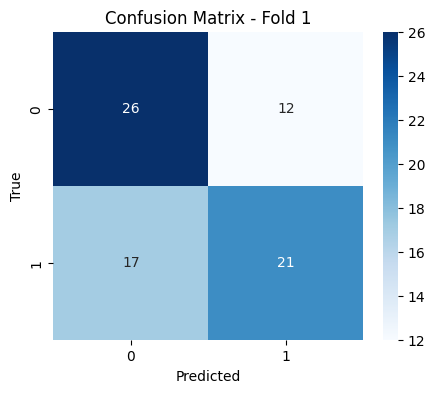

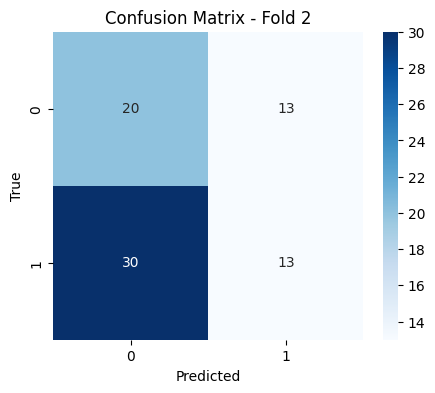

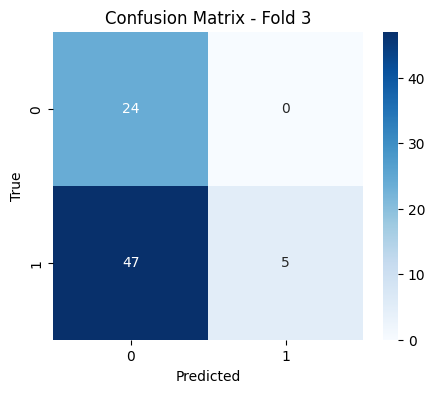

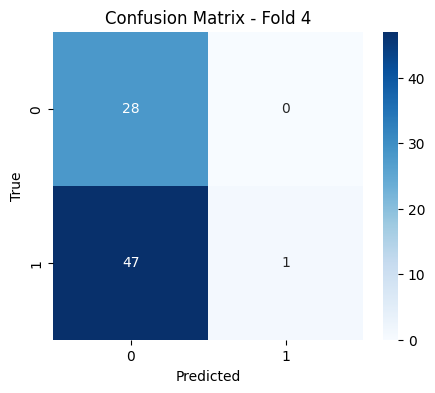

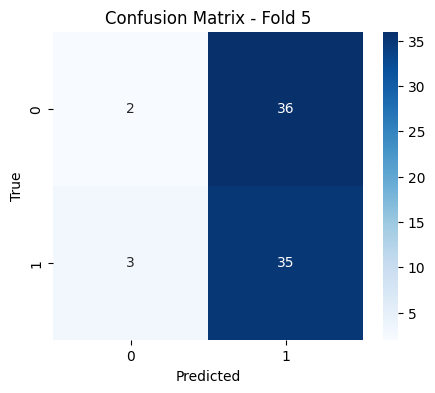

In [30]:
tscv = TimeSeriesSplit(n_splits=5)
feature_importances = np.zeros(len(features))
reports = []
fold = 1

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = XGBClassifier(eval_metric='logloss', random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    report = classification_report(y_test, y_pred, output_dict=True)
    roc_auc = roc_auc_score(y_test, y_proba)
    report['roc_auc'] = roc_auc
    reports.append(report)

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - Fold {fold}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    feature_importances += model.feature_importances_
    fold += 1

avg_precision = np.mean([r['1']['precision'] for r in reports])
avg_recall = np.mean([r['1']['recall'] for r in reports])
avg_f1 = np.mean([r['1']['f1-score'] for r in reports])
avg_roc_auc = np.mean([r['roc_auc'] for r in reports])

In [31]:
print("==== Cross-Validation Results ====")
print(f"Avg Precision (class 1): {avg_precision:.3f}")
print(f"Avg Recall (class 1): {avg_recall:.3f}")
print(f"Avg F1-Score (class 1): {avg_f1:.3f}")
print(f"Avg ROC AUC: {avg_roc_auc:.3f}")

==== Cross-Validation Results ====
Avg Precision (class 1): 0.726
Avg Recall (class 1): 0.379
Avg F1-Score (class 1): 0.365
Avg ROC AUC: 0.567


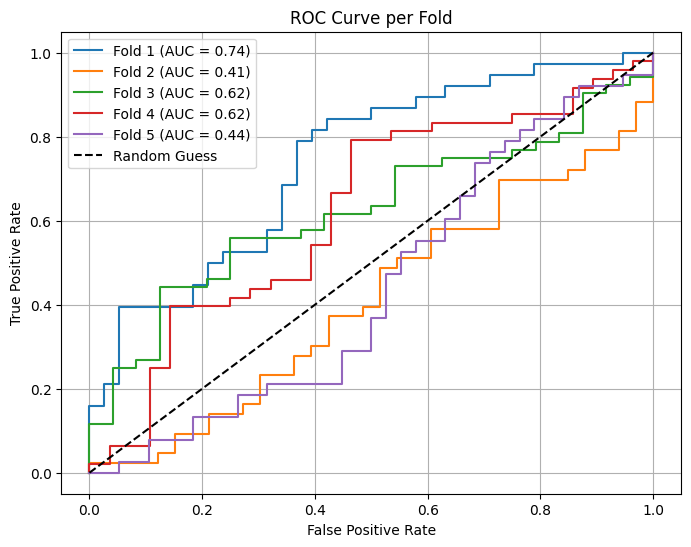

In [33]:
plt.figure(figsize=(8,6))


for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = XGBClassifier(eval_metric='logloss', random_state=42)
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Fold {fold} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve per Fold')
plt.legend()
plt.grid(True)
plt.show()

In [35]:
joblib.dump(model, 'models/rf_classifier.csv')

['models/rf_classifier.csv']